Markov Processes Homework #7 

1a. Problem setup and helper functions

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from math import exp, factorial, sqrt
from scipy.special import iv  # modified Bessel I_v

lambda_A_game = 2.0      
lambda_B_game = 1.5

# per-minute rates
rate_A = lambda_A_game / 90.0
rate_B = lambda_B_game / 90.0

def poisson_pmf(n, mu):
    return exp(-mu) * (mu ** n) / factorial(n)

def prob_A_wins(max_goals=30):
    total = 0.0
    for i in range(max_goals + 1):
        pA = poisson_pmf(i, lambda_A_game)
        for j in range(i):  # j < i means A wins
            pB = poisson_pmf(j, lambda_B_game)
            total += pA * pB
    return total

def tie_prob_no_goals_by_t(t):
    s = 1.0 - t / 90.0
    return exp(-3.5 * s) * iv(0, 2.0 * sqrt(3.0) * s)

def tie_prob_goal_at_60(t):
    if t < 60.0:
        return tie_prob_no_goals_by_t(t)
    else:
        s = (90.0 - t) / 90.0
        return 1.5 * s * exp(-3.5 * s)

def expected_A_goals_extra_time():
    mean_extra_time = 3.0  # minutes
    return rate_A * mean_extra_time




1a. Numerical Computation

In [6]:
p_A_win = prob_A_wins(max_goals=40)
p_tie_start = tie_prob_no_goals_by_t(0.0)
expected_extra = expected_A_goals_extra_time()

print("Problem 1 numerical answers:")
print(f"(a) P(A wins) = {p_A_win:.10f}")
print(f"(b) P(tie at end | no goals by t=0) = {p_tie_start:.10f}")
print(f"(d) E[A goals in extra time] = {expected_extra:.10f}")


Problem 1 numerical answers:
(a) P(A wins) = 0.4935624169
(b) P(tie at end | no goals by t=0) = 0.2161829633
(d) E[A goals in extra time] = 0.0666666667


1b. Plotted 

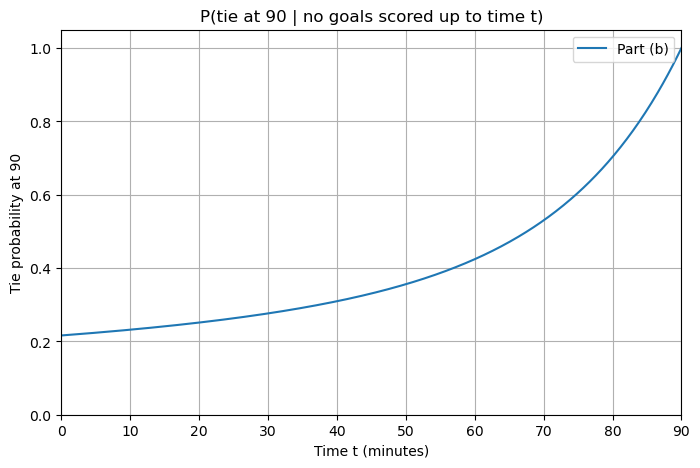

In [7]:
t_vals = np.linspace(0, 90, 500)
pb_vals = np.array([tie_prob_no_goals_by_t(t) for t in t_vals])

plt.figure(figsize=(8, 5))
plt.plot(t_vals, pb_vals, label="Part (b)")
plt.xlabel("Time t (minutes)")
plt.ylabel("Tie probability at 90")
plt.title("P(tie at 90 | no goals scored up to time t)")
plt.xlim(0, 90)
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()



1c. Plotted

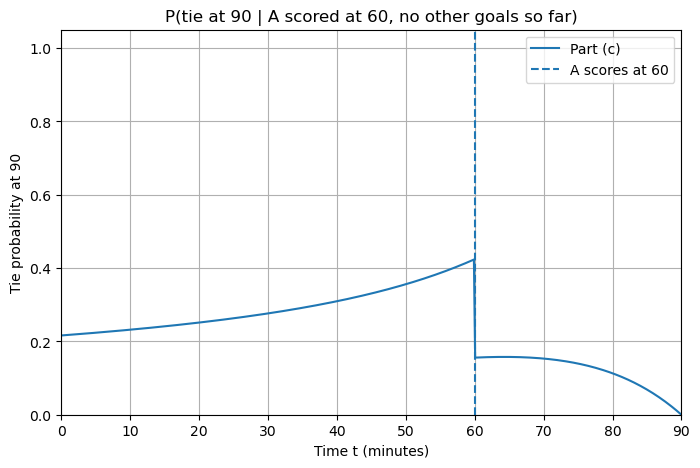

In [8]:
pc_vals = np.array([tie_prob_goal_at_60(t) for t in t_vals])

plt.figure(figsize=(8, 5))
plt.plot(t_vals, pc_vals, label="Part (c)")
plt.axvline(60, linestyle="--", label="A scores at 60")
plt.xlabel("Time t (minutes)")
plt.ylabel("Tie probability at 90")
plt.title("P(tie at 90 | A scored at 60, no other goals so far)")
plt.xlim(0, 90)
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

Problem 2 code, helper functions and setup. 

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import iv  # modified Bessel function I_v

lam = 3.0         
T = 48.0           
num_games = 100_000
rng = np.random.default_rng(42)

def simulate_hppp_times(rate, T, rng):
    times = []
    t = 0.0
    while True:
        t += rng.exponential(scale=1.0 / rate)
        if t > T:
            break
        times.append(t)
    return np.array(times)

def simulate_game_separate(lam, T, rng):
    times_A = simulate_hppp_times(lam, T, rng)
    times_B = simulate_hppp_times(lam, T, rng)
    return times_A, times_B

def plot_game(times_A, times_B, T, title):
    plt.figure(figsize=(10, 3))

    # A baskets at y = 1
    plt.vlines(times_A, 0.6, 1.4, label="Team A")
    # B baskets at y = -1
    plt.vlines(times_B, -1.4, -0.6, label="Team B")

    plt.xlim(0, T)
    plt.ylim(-2, 2)
    plt.yticks([-1, 1], ["Team B", "Team A"])
    plt.xlabel("Time (minutes)")
    plt.title(title)
    plt.grid(True, axis="x", alpha=0.3)
    plt.legend()
    plt.show()



2c. 

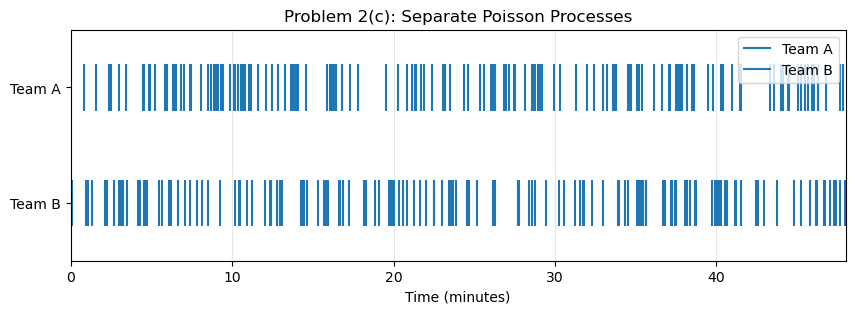

In [11]:
times_A_sep, times_B_sep = simulate_game_separate(lam, T, rng)
plot_game(times_A_sep, times_B_sep, T, "Problem 2(c): Separate Poisson Processes")

2d. 

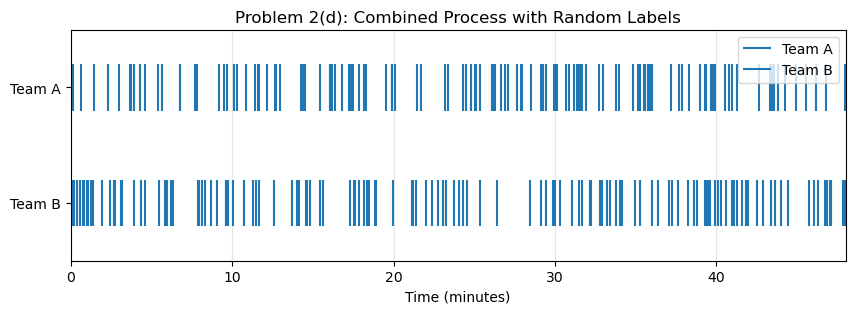

In [12]:
def simulate_game_combined(lam, T, rng):
    combined_rate = 2.0 * lam
    all_times = simulate_hppp_times(combined_rate, T, rng)

    labels = rng.random(len(all_times)) < 0.5
    times_A = all_times[labels]
    times_B = all_times[~labels]

    return times_A, times_B


times_A_comb, times_B_comb = simulate_game_combined(lam, T, rng)
plot_game(times_A_comb, times_B_comb, T, "Problem 2(d): Combined Process with Random Labels")

2e. 

In [ ]:
def simulate_many_games_efficient(lam, T, num_games, rng):
    mean_total = 2.0 * lam * T
    N = rng.poisson(mean_total, size=num_games)
    N_A = rng.binomial(N, 0.5)
    N_B = N - N_A
    D = 2 * (N_A - N_B)
    return D


D = simulate_manSy_games_efficient(lam, T, num_games, rng)

emp_mean = np.mean(D)
emp_var = np.var(D, ddof=1)
emp_tie_prob = np.mean(D == 0)

# theoretical values
theory_mean = 0.0
theory_var = 8.0 * lam * T
theory_tie_prob_exact = np.exp(-2.0 * lam * T) * iv(0, 2.0 * lam * T)
theory_tie_prob_asymp = 1.0 / np.sqrt(4.0 * np.pi * lam * T)

print("Problem 2(e) results")
print(f"Empirical mean of D(48):        {emp_mean:.6f}")
print(f"Theoretical mean of D(48):      {theory_mean:.6f}")
print()
print(f"Empirical variance of D(48):    {emp_var:.6f}")
print(f"Theoretical variance of D(48):  {theory_var:.6f}")
print()
print(f"Empirical P(D(48)=0):           {emp_tie_prob:.6f}")
print(f"Exact theoretical P(D(48)=0):   {theory_tie_prob_exact:.6f}")
print(f"Asymptotic approximation:       {theory_tie_prob_asymp:.6f}")

Problem 2(e) results
Empirical mean of D(48):        -0.127620
Theoretical mean of D(48):      0.000000

Empirical variance of D(48):    1154.095374
Theoretical variance of D(48):  1152.000000

Empirical P(D(48)=0):           0.024180
Exact theoretical P(D(48)=0):   0.023518
Asymptotic approximation:       0.023508


3c. 

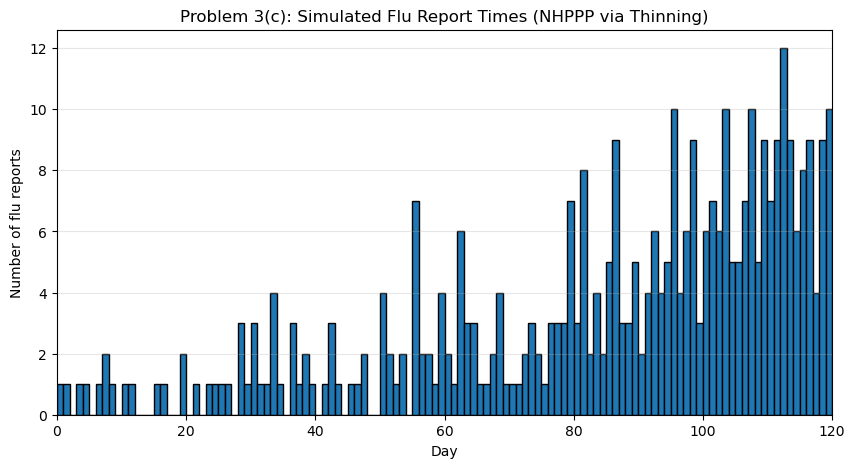

In [14]:
import numpy as np
import matplotlib.pyplot as plt

T = 120.0
lambda_max = 8.5   # maximum of lambda(t) on [0,120]
rng = np.random.default_rng(42)


def rate(t):
    return 0.5 * (1.0 + (t / 30.0) ** 2)

candidate_times = []
t = 0.0

while True:
    t += rng.exponential(scale=1.0 / lambda_max)
    if t > T:
        break
    candidate_times.append(t)

candidate_times = np.array(candidate_times)


accept_probs = rate(candidate_times) / lambda_max
uniforms = rng.random(len(candidate_times))
accepted_times = candidate_times[uniforms < accept_probs]


accept_probs = rate(candidate_times) / lambda_max
uniforms = rng.random(len(candidate_times))
accepted_times = candidate_times[uniforms < accept_probs]


bins = np.arange(0, 121, 1)   # day-by-day bins: [0,1), [1,2), ..., [119,120)

plt.figure(figsize=(10, 5))
plt.hist(accepted_times, bins=bins, edgecolor='black')
plt.xlabel("Day")
plt.ylabel("Number of flu reports")
plt.title("Problem 3(c): Simulated Flu Report Times (NHPPP via Thinning)")
plt.xlim(0, 120)
plt.grid(True, axis='y', alpha=0.3)
plt.show()